In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("nyc_taxi_cleaned_final.parquet")

df.shape

(7663542, 21)

In [4]:
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
        
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.dayofweek

In [5]:
df['tpep_pickup_datetime'].min()

Timestamp('2009-01-01 00:02:17')

In [6]:
df['tpep_pickup_datetime'].max()

Timestamp('2026-04-01 00:06:25')

In [7]:
df = df[
    (df['tpep_pickup_datetime'] >= '2026-01-01') &
    (df['tpep_pickup_datetime'] < '2026-04-01')
].copy()

In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_minutes,pickup_date,pickup_month,pickup_day,pickup_hour,pickup_weekday
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,15.86,2.5,0.0,0.00,5.550000,2026-01-01,January,Thursday,0,3
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,55.56,2.5,0.0,0.75,42.800000,2026-01-01,January,Thursday,0,3
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,...,24.94,2.5,0.0,0.75,13.600000,2026-01-01,January,Thursday,0,3
3,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,...,17.15,2.5,0.0,0.75,10.633333,2026-01-01,January,Thursday,0,3
4,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,...,51.66,2.5,0.0,0.75,37.733333,2026-01-01,January,Thursday,0,3


In [11]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_minutes,pickup_hour,pickup_weekday
count,7.663534e+06,7663534,7663534,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,...,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06,7.663534e+06
mean,1.781883e+00,2026-02-16 12:28:22.321443,2026-02-16 12:45:36.868382,1.243473e+00,3.421714e+00,1.074929e+00,1.650354e+02,1.647328e+02,1.144537e+00,1.953875e+01,...,3.614510e+00,5.837387e-01,9.546211e-01,2.906856e+01,2.224690e+00,1.530082e-01,5.298749e-01,1.724245e+01,1.436586e+01,2.999525e+00
min,1.000000e+00,2026-01-01 00:00:02,2026-01-01 00:02:02,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.666667e-02,0.000000e+00,0.000000e+00
25%,2.000000e+00,2026-01-23 20:42:29,2026-01-23 20:56:40,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,1.650000e+01,2.500000e+00,0.000000e+00,0.000000e+00,7.683333e+00,1.100000e+01,1.000000e+00
50%,2.000000e+00,2026-02-16 23:48:15.500000,2026-02-17 00:04:24.500000,1.000000e+00,1.690000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,...,2.950000e+00,0.000000e+00,1.000000e+00,2.160000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.270000e+01,1.500000e+01,3.000000e+00
75%,2.000000e+00,2026-03-11 18:08:41.750000,2026-03-11 18:26:57,1.000000e+00,3.340000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,...,4.480000e+00,0.000000e+00,1.000000e+00,3.114000e+01,2.500000e+00,0.000000e+00,7.500000e-01,2.110000e+01,1.900000e+01,5.000000e+00
max,2.000000e+00,2026-03-31 23:59:59,2026-04-01 01:22:42,8.000000e+00,5.000000e+01,6.000000e+00,2.650000e+02,2.650000e+02,4.000000e+00,9.500000e+02,...,1.000000e+02,1.222200e+02,1.000000e+00,9.510000e+02,2.500000e+00,5.000000e+00,7.500000e-01,1.799667e+02,2.300000e+01,6.000000e+00
std,4.129675e-01,NaN,NaN,6.393246e-01,4.513627e+00,4.228960e-01,6.366389e+01,6.961328e+01,4.220742e-01,1.769537e+01,...,3.979331e+00,2.260863e+00,2.081338e-01,2.212522e+01,7.826100e-01,5.027685e-01,3.415242e-01,1.529856e+01,5.583055e+00,1.894552e+00


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7663534 entries, 0 to 7663541
Data columns (total 26 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

In [13]:
df.groupby("pickup_month")["total_amount"].sum()

pickup_month
February    66113262.11
January     72471660.05
March       84183005.65
Name: total_amount, dtype: float64

In [14]:
df.groupby("pickup_day")["total_amount"].count()

pickup_day
Friday       1211443
Monday        905543
Saturday     1146300
Sunday        873443
Thursday     1259434
Tuesday      1144010
Wednesday    1123361
Name: total_amount, dtype: int64

In [15]:
df.groupby("pickup_hour")["total_amount"].count()

pickup_hour
0     184764
1     119642
2      76573
3      53807
4      38757
5      49161
6     103541
7     205487
8     287231
9     335898
10    364742
11    392054
12    424770
13    439789
14    474046
15    501111
16    510683
17    547535
18    554069
19    481309
20    441271
21    439805
22    370876
23    266613
Name: total_amount, dtype: int64

In [16]:
df['total_amount'].sum()

np.float64(222767927.81000012)

In [17]:
# Which payment method is most popular?
df['payment_type'].value_counts()

payment_type
1    6702662
2     876119
4      62040
3      22713
Name: count, dtype: int64

In [18]:
# Which vendor completed more trips
df['VendorID'].value_counts()

VendorID
2    5991985
1    1671549
Name: count, dtype: int64

In [19]:
# How many passengers usually travel?
df['passenger_count'].value_counts().sort_index()

passenger_count
1.0    6374217
2.0     929174
3.0     197036
4.0     123956
5.0      25012
6.0      14136
7.0          1
8.0          2
Name: count, dtype: int64

In [20]:
# What's the average distance?
df['trip_distance'].describe()

count    7.663534e+06
mean     3.421714e+00
std      4.513627e+00
min      1.000000e-02
25%      1.000000e+00
50%      1.690000e+00
75%      3.340000e+00
max      5.000000e+01
Name: trip_distance, dtype: float64

In [21]:
payment_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

df["payment_name"] = df["payment_type"].map(payment_map)

In [22]:
# Revenue by Payment Type
df.groupby("payment_name")["total_amount"].sum().sort_values(ascending=False)

payment_name
Credit Card    1.984396e+08
Cash           2.198587e+07
Dispute        1.783912e+06
No Charge      5.585816e+05
Name: total_amount, dtype: float64

In [23]:
df["payment_name"].value_counts(normalize=True) * 100

payment_name
Credit Card    87.461764
Cash           11.432310
Dispute         0.809548
No Charge       0.296378
Name: proportion, dtype: float64

In [24]:
df['fare_amount'].describe()

count    7.663534e+06
mean     1.953875e+01
std      1.769537e+01
min      1.000000e-02
25%      9.300000e+00
50%      1.350000e+01
75%      2.190000e+01
max      9.500000e+02
Name: fare_amount, dtype: float64

In [25]:
# Avg Fare per Trip
df["total_amount"].mean()

np.float64(29.068563904068295)

In [26]:
df['tip_amount'].max()

100.0

In [27]:
df[['trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_duration_minutes']].corr()

,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_minutes
trip_distance,1.000000,0.917787,0.519411,0.896192,0.775710
fare_amount,0.917787,1.000000,0.582444,0.972985,0.767435
tip_amount,0.519411,0.582444,1.000000,0.723332,0.351686
total_amount,0.896192,0.972985,0.723332,1.000000,0.711195
trip_duration_minutes,0.775710,0.767435,0.351686,0.711195,1.000000


In [28]:
#Top 10 Pickup Locations
top_locations = df.groupby("PULocationID")["total_amount"].mean().nlargest(10)
top_locations

PULocationID
1      110.314648
265     88.191379
93      84.216903
132     79.343414
23      78.675500
216     77.291321
10      75.002361
219     72.709485
207     72.007722
199     71.850000
Name: total_amount, dtype: float64

In [29]:
# Tip Behavior
df.groupby("payment_type")["tip_amount"].mean()

payment_type
1    4.132591
2    0.000337
3    0.000800
4    0.003942
Name: tip_amount, dtype: float64

In [30]:
df = df[
    (df["total_amount"] >= df["fare_amount"]) &
    (df["fare_amount"] > 0) &
    (df["trip_distance"] > 0)
].copy()

In [31]:
# Longest Trips
df.sort_values("trip_distance", ascending=False)[
    ["trip_distance", "fare_amount", "tip_amount", "total_amount"]
].head(10)

,trip_distance,fare_amount,tip_amount,total_amount
2765180,50.00,175.0,0.00,207.46
3884601,50.00,45.5,0.00,46.00
4728415,49.98,280.0,0.00,296.21
4714618,49.97,246.6,55.86,336.92
6233432,49.97,319.4,66.82,400.93
4566282,49.95,298.4,62.87,378.98
4864415,49.95,334.1,20.00,357.35
3599151,49.93,229.1,0.00,262.56
5874934,49.88,310.3,5.00,321.05
1276012,49.87,187.8,50.00,254.34


In [32]:
# Revenue per Passenger
df.groupby("passenger_count")["total_amount"].mean()

passenger_count
1.0    28.399286
2.0    32.287148
3.0    31.980038
4.0    35.526534
5.0    25.818440
6.0    27.824888
7.0    88.750000
8.0    98.375000
Name: total_amount, dtype: float64

In [33]:
# Long vs Short Trips
df["trip_type"] = df["trip_distance"].apply(lambda x: "Short" if x < 3 else "Long")
df.groupby("trip_type")["total_amount"].mean()

trip_type
Long     53.409779
Short    19.668947
Name: total_amount, dtype: float64

In [34]:
df["trip_distance"].describe()

count    7.663534e+06
mean     3.421714e+00
std      4.513627e+00
min      1.000000e-02
25%      1.000000e+00
50%      1.690000e+00
75%      3.340000e+00
max      5.000000e+01
Name: trip_distance, dtype: float64

In [35]:
df['avg_speed'] = (
    df['trip_distance'] /
    (df['trip_duration_minutes'] / 60)
)

df['avg_speed'].describe()

count    7.663534e+06
mean     1.086549e+01
std      5.412450e+01
min      4.999306e-03
25%      6.676364e+00
50%      8.953846e+00
75%      1.228895e+01
max      6.746400e+04
Name: avg_speed, dtype: float64

In [36]:
df["speed_category"] = pd.qcut(
    df["avg_speed"],
    q=4,
    labels=["Slow", "Normal", "Fast", "Highway"]
)

In [37]:
df.groupby(["trip_type", "speed_category"])["total_amount"].mean()

C:\Users\Ritu\AppData\Local\Temp\ipykernel_12600\70778395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trip_type", "speed_category"])["total_amount"].mean()


trip_type  speed_category
Long       Slow              38.804034
           Normal            37.874319
           Fast              39.967339
           Highway           61.760653
Short      Slow              21.368466
           Normal            19.335848
           Fast              18.407056
           Highway           18.464666
Name: total_amount, dtype: float64

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
sns.set_style("whitegrid")

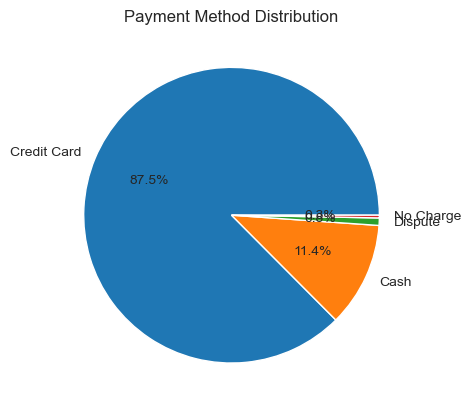

In [40]:
# 1. PAYMENT DISTRIBUTION 
payment_dist = df["payment_name"].value_counts()

plt.figure()
payment_dist.plot.pie(autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

- A significant majority of customers prefer credit card payments, highlighting strong adoption of digital transactions over cash

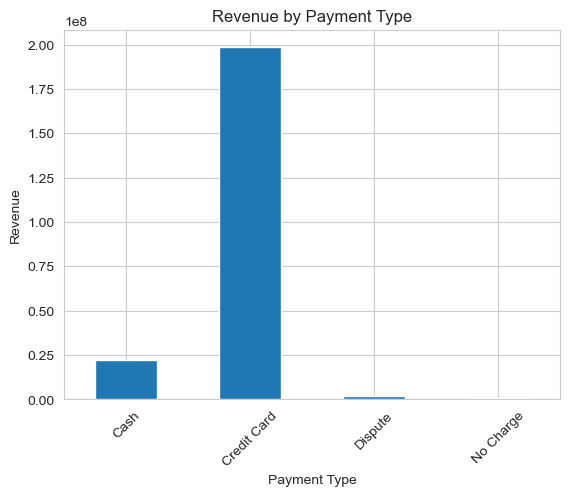

In [41]:
# 2.REVENUE BY PAYMENT
payment_rev = df.groupby("payment_name")["total_amount"].sum()

plt.figure()
payment_rev.plot(kind="bar")
plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

- Credit card transactions generate the highest revenue due to both higher usage frequency and larger average transaction values.

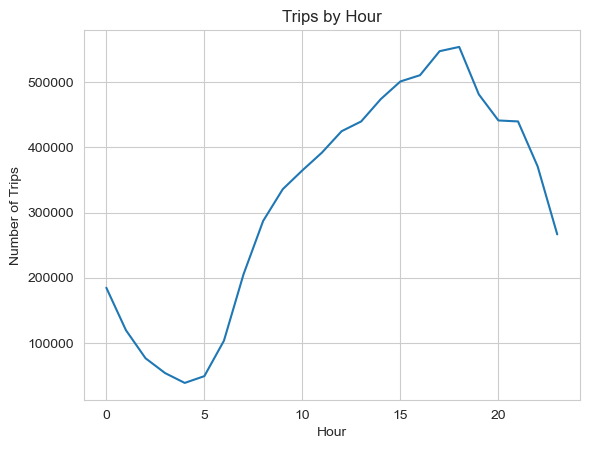

In [42]:
# 3. TRIPS BY HOUR 
hourly_trips = df.groupby("pickup_hour")["VendorID"].count()

plt.figure()
hourly_trips.plot()
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

- Trip demand is lowest during early morning hours and gradually increases throughout the day, peaking in the evening between 4 PM and 7 PM due to office return traffic.

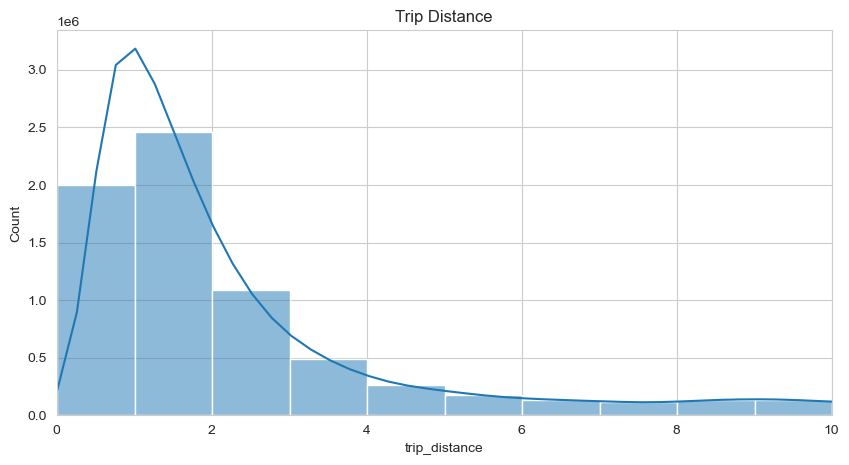

In [43]:
# TRIP DISTANCE DISTRIBUTION
plt.figure(figsize=(10,5))
sns.histplot(df["trip_distance"], bins=50, kde=True)

plt.xlim(0, 10)
plt.title("Trip Distance")
plt.show()

- Trip distances are heavily concentrated within short ranges (0–3 miles), indicating that most taxi rides are short-distance urban trips.

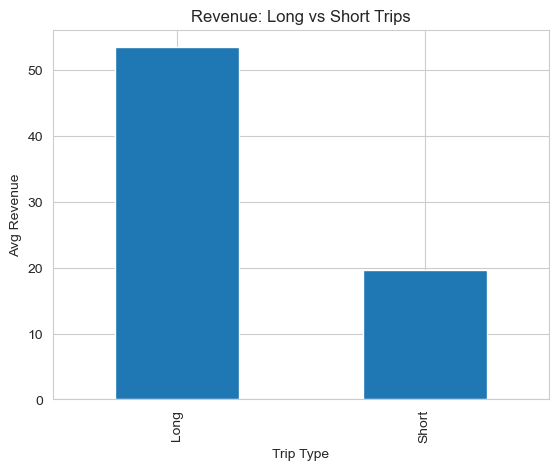

In [44]:
# LONG VS SHORT TRIPS
trip_type_rev = df.groupby("trip_type")["total_amount"].mean()

plt.figure()
trip_type_rev.plot(kind="bar")
plt.title("Revenue: Long vs Short Trips")
plt.xlabel("Trip Type")
plt.ylabel("Avg Revenue")
plt.show()

- Long-distance trips contribute significantly higher revenue per ride, while short trips dominate overall trip volume.

C:\Users\Ritu\AppData\Local\Temp\ipykernel_12600\2789989393.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  speed_rev = df.groupby("speed_category")["total_amount"].mean()


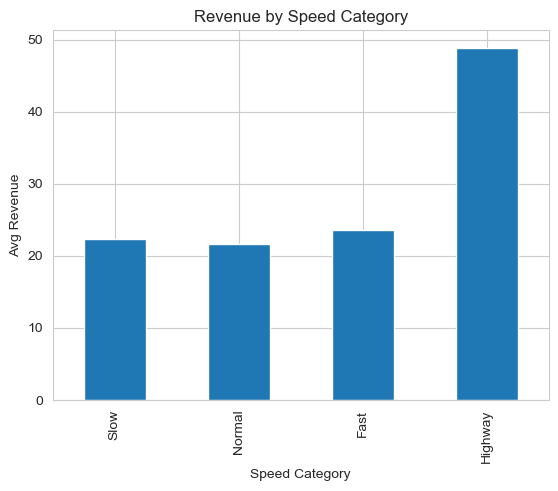

In [45]:
# SPEED VS REVENUE
speed_rev = df.groupby("speed_category")["total_amount"].mean()

plt.figure()
speed_rev.plot(kind="bar")
plt.title("Revenue by Speed Category")
plt.xlabel("Speed Category")
plt.ylabel("Avg Revenue")
plt.show()

- Trips with higher average speeds tend to generate more revenue, suggesting that longer-distance or highway rides contribute more to total earnings.

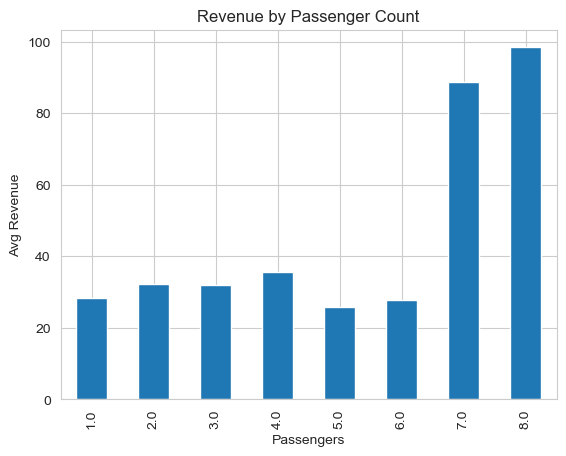

In [46]:
# PASSENGER COUNT
passenger_rev = df.groupby("passenger_count")["total_amount"].mean()

plt.figure()
passenger_rev.plot(kind="bar")
plt.title("Revenue by Passenger Count")
plt.xlabel("Passengers")
plt.ylabel("Avg Revenue")
plt.show()

- Revenue remains relatively stable for smaller passenger groups, while higher passenger counts show increased revenue, possibly due to group travel.

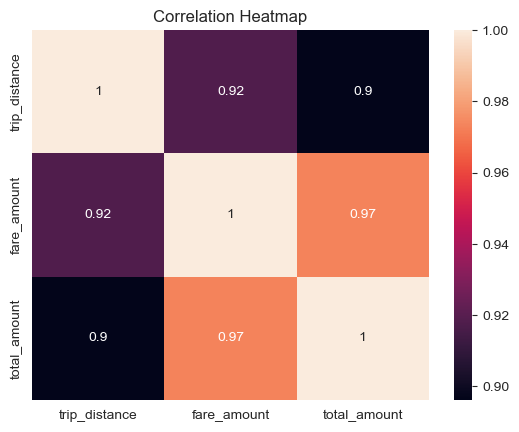

In [47]:
#  CORRELATION HEATMAP
plt.figure()
sns.heatmap(
    df[["trip_distance","fare_amount","total_amount"]].corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

- There is a strong positive correlation between trip distance, fare amount, and total amount, indicating that pricing is primarily driven by distance.

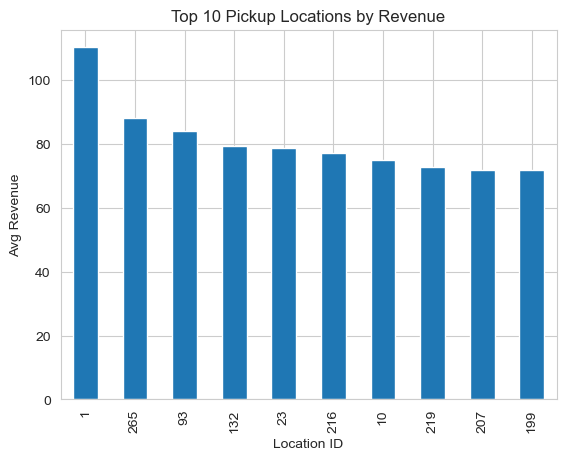

In [48]:
# TOP LOCATIONS
top_loc = df.groupby("PULocationID")["total_amount"].mean().nlargest(10)

plt.figure()
top_loc.plot(kind="bar")
plt.title("Top 10 Pickup Locations by Revenue")
plt.xlabel("Location ID")
plt.ylabel("Avg Revenue")
plt.show()


- Certain pickup locations consistently generate higher revenue, indicating high-demand zones and potential areas for optimized driver allocation.

In [49]:
# !pip install pymysql sqlalchemy

In [ ]:
df.to_csv(
    r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\nyc_taxi_clean.csv",
    index=False
)